<a href="https://colab.research.google.com/github/seigdev/artificial-intelligence/blob/main/assessments/assignment_one.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [82]:
!pip3 install Levenshtein

^C


In [111]:
import pandas as pd
import requests
import numpy as np
import tensorflow as tf
import tensorflow_hub as hub
import matplotlib.pyplot as plt
import gensim
import re
import nltk
import tldextract
import seaborn as sns
from urllib.parse import urlparse
from Levenshtein import distance as levenshtein_distance
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras import losses

## data collection

In [22]:
def fetch_crypto_datasets(url):
    # Make the request
    response = requests.get(url)
    if response.status_code == 200:
        # Return the JSON data
        return response.json()
    else:
        print(f"Failed to fetch data. Status code: {response.status_code}. Reason: {response.reason}")

        return []

In [23]:
datasets_raw = fetch_crypto_datasets("https://raw.githubusercontent.com/seigdev/artificial-intelligence/refs/heads/main/crypto_data.json")

In [115]:
datasets_df = pd.DataFrame(datasets_raw)

## eda

In [25]:
# view the first few rows
datasets_df.head()

,url,label,label_no
0,https://arbitrum-claim.net,scam,1
1,https://allocate-dym.network,scam,1
2,https://rionegro.com.ar,legit,0
3,https://net-layerzero.com,scam,1
4,https://leugss.top,scam,1


In [26]:
# basic info
print(datasets_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   url       100000 non-null  object
 1   label     100000 non-null  object
 2   label_no  100000 non-null  object
dtypes: object(3)
memory usage: 2.3+ MB
None


In [27]:
# count the number of scam and legitimate links
datasets_df["label"].value_counts()

label
scam     80000
legit    20000
Name: count, dtype: int64

In [28]:
# Summary statistics for numerical columns (if any)
datasets_df.describe()

,url,label,label_no
count,100000,100000,100000
unique,99680,2,2
top,https://app.uniswap.org/swap,scam,1
freq,22,80000,80000


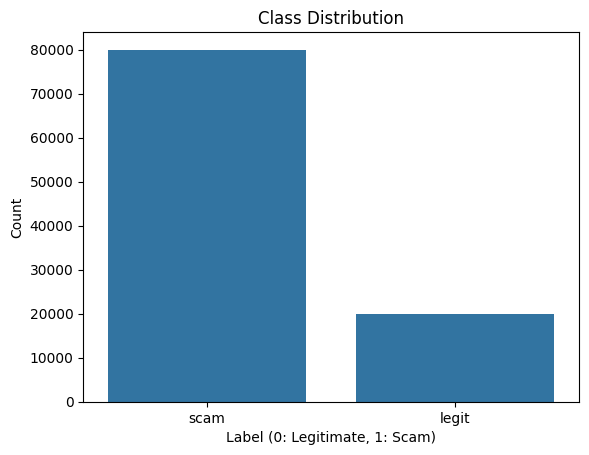

In [29]:
#  count the number of scam and legitimate links
class_distribution = datasets_df["label"].value_counts()

# plot the distribution
sns.barplot(x=class_distribution.index, y=class_distribution.values)
plt.title("Class Distribution")
plt.xlabel("Label (0: Legitimate, 1: Scam)")
plt.ylabel("Count")
plt.show()

Unique domains: 65170
Top TLDs: tld
com       34117
io        10692
xyz        5337
net        5153
app        4701
org        4336
dev        3922
top        1845
online     1564
site       1511
Name: count, dtype: int64


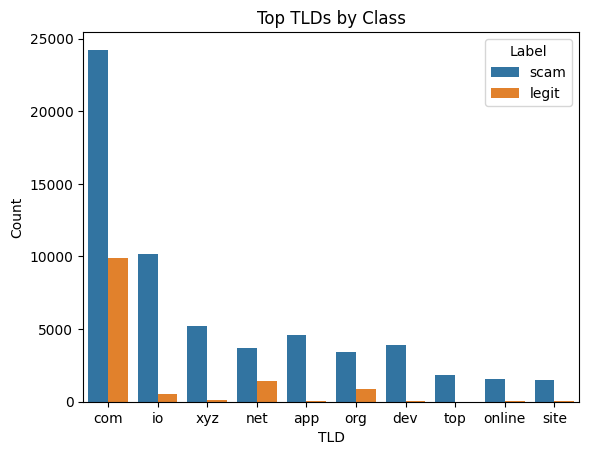

In [30]:
# extract domain and TLD
datasets_df["domain"] = datasets_df["url"].apply(lambda x: tldextract.extract(x).domain)
datasets_df["tld"] = datasets_df["url"].apply(lambda x: tldextract.extract(x).suffix)

# count unique domains and TLDs
print("Unique domains:", datasets_df["domain"].nunique())
print("Top TLDs:", datasets_df["tld"].value_counts().head(10))

# compare TLDs for scam vs. legitimate links
sns.countplot(x="tld", hue="label", data=datasets_df, order=datasets_df["tld"].value_counts().iloc[:10].index)
plt.title("Top TLDs by Class")
plt.xlabel("TLD")
plt.ylabel("Count")
plt.legend(title="Label", loc="upper right")
plt.show()

In [31]:
datasets_df.drop(columns=["label"], inplace=True)

## preprocessing

In [75]:
def clean_url(url):
    url = re.sub(r'https?://(www\.)?', '', url.lower())

    url = re.sub(r'\.[a-z]{2,3}(?=\/|$)', '', url)

    tokens = re.split(r'[/?=&.-]', url)
    tokens = [token for token in tokens if token] 
    
    return " ".join(tokens)

# Apply cleaning to DataFrame
datasets_df['cleaned_url'] = datasets_df['url'].apply(clean_url)

In [76]:
# Feature Extraction Function
def extract_features(url):
    features = {}
    features['url_length'] = len(url)
    features['num_digits'] = sum(c.isdigit() for c in url)
    features['num_special_chars'] = len(re.findall(r'[^a-zA-Z0-9]', url))
    features['num_subdomains'] = url.count('.')
    features['has_https'] = 1 if 'https' in url else 0
    features['suspicious_keywords'] = sum(kw in url for kw in ["free", "bonus", "earn", "crypto", "win"])
    return features

# Apply feature extraction
df_features = datasets_df['url'].apply(lambda x: pd.Series(extract_features(x)))

In [77]:
datasets_df

,url,label_no,domain,tld,cleaned_url
0,https://arbitrum-claim.net,1,arbitrum-claim,net,arbitrum claim
1,https://allocate-dym.network,1,allocate-dym,network,allocate dym network
2,https://rionegro.com.ar,0,rionegro,com.ar,rionegro com
3,https://net-layerzero.com,1,net-layerzero,com,net layerzero
4,https://leugss.top,1,leugss,top,leugss
...,...,...,...,...,...
99995,https://youversionapi.com,0,youversionapi,com,youversionapi
99996,https://saintssinnersnft.com,1,saintssinnersnft,com,saintssinnersnft
99997,https://convexfinence.com,1,convexfinence,com,convexfinence
99998,https://app.velar.co/swap,0,velar,co,app velar swap


## feature engineering

In [78]:
# function to detect typosquatting
def detect_typosquatting(url, legitimate_domains, threshold=2):
    parsed_url = urlparse(url)
    domain = parsed_url.netloc.lower()

    for legit_domain in legitimate_domains:
        if levenshtein_distance(domain, legit_domain) <= threshold:
            return 1
    return 0

In [79]:
# Splitting dataset
X_train, X_test, y_train, y_test = train_test_split(datasets_df['cleaned_url'], datasets_df['label_no'], test_size=0.2, random_state=42)
X_train_features, X_test_features = train_test_split(df_features, test_size=0.2, random_state=42)

In [80]:
map = {0: "legit", 1: "scam"}
map

{0: 'legit', 1: 'scam'}

#### word2Vec

In [84]:
# Train custom Word2Vec model
sentences = [word_tokenize(url) for url in datasets_df['cleaned_url'].tolist()]

# Initialize and build vocabulary in one step
word2vec_model = gensim.models.Word2Vec(
    sentences=sentences,  # This builds the vocabulary automatically
    vector_size=300,
    window=5,
    min_count=1,
    workers=4
)

# # Now train the model
word2vec_model.train(
    sentences,
    total_examples=word2vec_model.corpus_count,
    epochs=10
)

# # Save the trained model
word2vec_model.save("word2vec_model.bin")

In [85]:
# Build embedding matrix from trained Word2Vec
embedding_matrix = np.zeros((len(word2vec_model.wv) + 1, 300))
for i, word in enumerate(word2vec_model.wv.index_to_key):
    embedding_matrix[i] = word2vec_model.wv[word]

#### TF-IDF

In [86]:
# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Combine lexical and TF-IDF features
X_train_combined = np.hstack((X_train_tfidf.toarray(), X_train_features.to_numpy()))
X_test_combined = np.hstack((X_test_tfidf.toarray(), X_test_features.to_numpy()))

#### nnlm-50

In [91]:
# load NNLM embeddings (50-dimensional)
embed_50 = hub.load("https://tfhub.dev/google/nnlm-en-dim50/2")

# fetch embeddings of urls
X_embeddings_50 = embed_50(datasets_df["cleaned_url"].tolist()).numpy()

X_embeddings_50

2025-03-24 22:50:18.579261: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'sentences' with dtype string and shape [?]
	 [[{{node sentences}}]]


array([[ 0.03077845, -0.26711562,  0.01830282, ...,  0.2072107 ,
         0.02002396,  0.11362913],
       [ 0.12560877, -0.11177091, -0.02211482, ...,  0.00737813,
         0.40654805,  0.32076135],
       [ 0.21852288, -0.2228536 , -0.00697529, ...,  0.24107803,
         0.09248105,  0.0685963 ],
       ...,
       [ 0.42437407,  0.17515412,  0.0380774 , ...,  0.06362747,
        -0.03616028,  0.16073953],
       [-0.02407272, -0.12908407,  0.06917293, ...,  0.07424267,
         0.23407026,  0.15360208],
       [ 0.20205095,  0.2557025 ,  0.00315733, ...,  0.2201928 ,
        -0.03696417, -0.01444183]], dtype=float32)

#### nnlm-128

In [92]:
# using nnlm-128

# load NNLM embeddings (128-dimensional)
embed_128 = hub.load("https://tfhub.dev/google/nnlm-en-dim50/2")

# fetch embeddings of urls
X_embeddings_128 = embed_128(datasets_df["cleaned_url"].tolist()).numpy()

X_embeddings_128

2025-03-24 22:50:21.997152: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'sentences' with dtype string and shape [?]
	 [[{{node sentences}}]]


array([[ 0.03077845, -0.26711562,  0.01830282, ...,  0.2072107 ,
         0.02002396,  0.11362913],
       [ 0.12560877, -0.11177091, -0.02211482, ...,  0.00737813,
         0.40654805,  0.32076135],
       [ 0.21852288, -0.2228536 , -0.00697529, ...,  0.24107803,
         0.09248105,  0.0685963 ],
       ...,
       [ 0.42437407,  0.17515412,  0.0380774 , ...,  0.06362747,
        -0.03616028,  0.16073953],
       [-0.02407272, -0.12908407,  0.06917293, ...,  0.07424267,
         0.23407026,  0.15360208],
       [ 0.20205095,  0.2557025 ,  0.00315733, ...,  0.2201928 ,
        -0.03696417, -0.01444183]], dtype=float32)

## modelling

#### logistics regression

/Users/sooreoluwa/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 0.8583
              precision    recall  f1-score   support

           0       0.68      0.53      0.60      3943
           1       0.89      0.94      0.91     16057

    accuracy                           0.86     20000
   macro avg       0.79      0.73      0.76     20000
weighted avg       0.85      0.86      0.85     20000



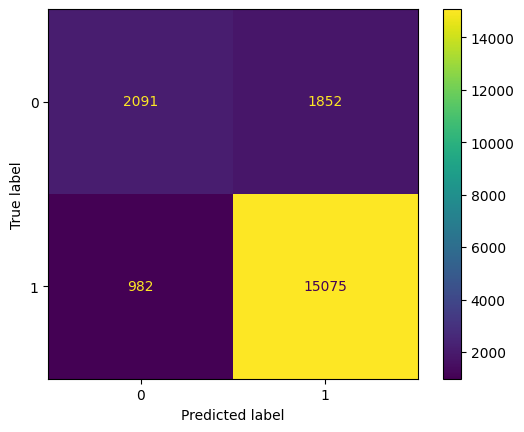

In [90]:
lr = LogisticRegression()
lr.fit(X_train_combined, y_train)
lr_preds = lr.predict(X_test_combined)
confusion = confusion_matrix(y_test, lr_preds)
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_preds))
print(classification_report(y_test, lr_preds))  
disp = ConfusionMatrixDisplay(confusion, display_labels = map.keys())
disp.plot()
plt.show()

In [113]:
# Tokenizing for NN models
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train)

# Rebuild embedding matrix to match Tokenizer's vocabulary
vocab_size = embedding_matrix.shape[0]
embedding_matrix = np.zeros((vocab_size, 300))

for word, i in tokenizer.word_index.items():
    if word in word2vec_model.wv:
        embedding_matrix[i] = word2vec_model.wv[word]

# Then use as before
X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=50)
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=50)

print("X_train_seq type:", type(X_train_seq[0][0]))  # Should be int/float
print("y_train type:", type(y_train[0])) 

X_train_seq type: <class 'numpy.int32'>
y_train type: <class 'str'>


#### LSTM

In [112]:
# Example: Focal Loss (for class imbalance)
def focal_loss(y_true, y_pred, alpha=0.25, gamma=2):
    # Custom implementation
    return losses.binary_crossentropy(y_true, y_pred) * alpha * (1 - y_pred)**gamma

# Build LSTM model
lstm_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=300, weights=[embedding_matrix], input_length=50, trainable=True),
    LSTM(64, return_sequences=True),
    LSTM(32),
    Dense(1, activation='softmax')
])
lstm_model.compile(optimizer='adam', loss=focal_loss, metrics=['accuracy'])
lstm_model.fit(X_train_seq, y_train, epochs=5, validation_data=(X_test_seq, y_test))

2025-03-24 23:17:08.045426: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-03-24 23:17:08.048554: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-03-24 23:17:08.049963: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

Epoch 1/5


2025-03-24 23:17:08.307114: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-03-24 23:17:08.309056: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-03-24 23:17:08.311223: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

UnimplementedError: Graph execution error:

Detected at node 'focal_loss/Cast' defined at (most recent call last):
    File "/Applications/Xcode.app/Contents/Developer/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/runpy.py", line 197, in _run_module_as_main
      return _run_code(code, main_globals, None,
    File "/Applications/Xcode.app/Contents/Developer/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/runpy.py", line 87, in _run_code
      exec(code, run_globals)
    File "/Users/sooreoluwa/Library/Python/3.9/lib/python/site-packages/ipykernel_launcher.py", line 18, in <module>
      app.launch_new_instance()
    File "/Users/sooreoluwa/Library/Python/3.9/lib/python/site-packages/traitlets/config/application.py", line 1075, in launch_instance
      app.start()
    File "/Users/sooreoluwa/Library/Python/3.9/lib/python/site-packages/ipykernel/kernelapp.py", line 739, in start
      self.io_loop.start()
    File "/Users/sooreoluwa/Library/Python/3.9/li

#### CNN

In [ ]:
# Build CNN model
cnn_model = Sequential([
    Embedding(input_dim=len(word2vec_model.wv) + 1, output_dim=300, weights=[embedding_matrix], input_length=50, trainable=True),
    Conv1D(128, 5, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])
cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cnn_model.fit(X_train_seq, y_train, epochs=5, validation_data=(X_test_seq, y_test))

NameError: name 'word2vec_model' is not defined